In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import os
from dotenv import load_dotenv
import google.generativeai as genai

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12872\4072843367.py:12: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [9]:
# Load and Prepare Data
df = pd.read_csv("../../data/processed/merged_health_data.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

In [10]:
# Compute Enhanced Health Index (HI_v2) using Sub-Indices

# Base References (Calibrated to Real Data)
S_ref = 5500
HR_norm = 80
HR_max_ref = 180
HR_min_ref = 50
SpO2_ref = 98
SpO2_min_ref = 95
SpO2_max_ref = 100

Posture_asym_ref = 1.6   # Reference for low shoulder asymmetry (in pixels)
Slouch_ref = 177       # Reference angle for good posture (degrees)

Jitter_ref = 0.004      # Reference for normal voice jitter
Shimmer_ref = 0.04     # Reference for normal voice shimmer
HNR_ref = 20           # Harmonic-to-Noise Ratio (higher is better)
F1_ref = 600           # Generic Formant 1 reference (Hz)
F2_ref = 1150          # Generic Formant 2 reference (Hz)

# Calculate Sub-Indices and save them as dataframe columns

# Activity Score
df["activity_score"] = df["daily_step_count"] / S_ref

# Cardio Score
df["cardio_score"] = (
    0.6 * (HR_norm / df["avg_heart_rate"]) +
    0.2 * (HR_max_ref / (df["max_heart_rate"] + 1)) + # +1 to avoid div by zero issues
    0.2 * (df["min_heart_rate"] / HR_min_ref)
)

# Respiratory Score
df["resp_score"] = (
    0.6 * (df["avg_spo2"] / SpO2_ref) +
    0.2 * (df["min_spo2"] / SpO2_min_ref) +
    0.2 * (df["max_spo2"] / SpO2_max_ref)
)

# Posture Score
df["posture_score"] = (
    0.5 * (Posture_asym_ref / (df["shoulder_asymmetry"] + 1)) +
    0.5 * (df["slouch_angle"] / Slouch_ref)
)

# Vocal/Stress Score
df["vocal_score"] = (
    0.3 * (Jitter_ref / df["Jitter"]) +
    0.3 * (Shimmer_ref / df["Shimmer"]) +
    0.2 * (df["HNR"] / HNR_ref) +
    0.1 * (F1_ref / df["F1"]) +
    0.1 * (F2_ref / df["F2"])
)

# Final HI_v2 Calculation
# Sub-Index weights
w_act, w_car, w_res, w_pos, w_voc = 0.35, 0.25, 0.20, 0.10, 0.10

df["HI_v2"] = (
    w_act * df["activity_score"] +
    w_car * df["cardio_score"] +
    w_res * df["resp_score"] +
    w_pos * df["posture_score"] +
    w_voc * df["vocal_score"]
)

In [11]:
# Feature Engineering and Train/Test Split
from sklearn.preprocessing import StandardScaler

# Features for Linear Regression and Random Forest
df_model = df.copy()
df_model["HI_v2_next"] = df_model["HI_v2"].shift(-1)
df_model = df_model.dropna()

# Select the 5 sub-indices as input features (X) instead of just HI_v2
feature_cols = ["activity_score", "cardio_score", "resp_score", "posture_score", "vocal_score"]
X_raw = df_model[feature_cols].values
y = df_model["HI_v2_next"].values

# Standardize the features so their scales are identical (mean=0, std=1)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

split = int(len(df_model) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [12]:
# Train and Evaluate Linear Regression
print("Training Linear Regression")
tscv = TimeSeriesSplit(n_splits=5)
lr_maes = []
lr_rmses = []

final_lr_model = LinearRegression()

for train_index, test_index in tscv.split(X):
    X_train_cv, X_test_cv = X[train_index], X[test_index]
    y_train_cv, y_test_cv = y[train_index], y[test_index]
    
    lr_model_cv = LinearRegression()
    lr_model_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv = lr_model_cv.predict(X_test_cv)
    
    lr_maes.append(mean_absolute_error(y_test_cv, y_pred_cv))
    lr_rmses.append(math.sqrt(mean_squared_error(y_test_cv, y_pred_cv)))
    
    final_lr_model = lr_model_cv

mae_lr = np.mean(lr_maes)
rmse_lr = np.mean(lr_rmses)

print(f"Linear Regression Average MAE (from CV): {mae_lr:.4f}")
print(f"Linear Regression Average RMSE (from CV): {rmse_lr:.4f}\n")

# Random Forest with Extensive GridSearchCV
print("Tuning and Training Random Forest")

# Define an expanded parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

# Use TimeSeriesSplit for cross-validation in GridSearchCV
tscv_grid_rf = TimeSeriesSplit(n_splits=5)

rf_model = RandomForestRegressor(random_state=42)

rf_grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=tscv_grid_rf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

rf_grid_search.fit(X_train, y_train)

# Get the best model
best_rf_model = rf_grid_search.best_estimator_
print(f"\nBest Random Forest Parameters: {rf_grid_search.best_params_}")

# Evaluate the best model on the test set
y_pred_rf = best_rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = math.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"\nRandom Forest (Tuned) MAE on Test Set: {mae_rf:.4f}")
print(f"Random Forest (Tuned) RMSE on Test Set: {rmse_rf:.4f}")

# Generate predictions from the final LR model on the test set for plotting
y_pred_lr = final_lr_model.predict(X_test)

Training Linear Regression
Linear Regression Average MAE (from CV): 0.0971
Linear Regression Average RMSE (from CV): 0.1221

Tuning and Training Random Forest
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best Random Forest Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

Random Forest (Tuned) MAE on Test Set: 0.0877
Random Forest (Tuned) RMSE on Test Set: 0.1098


In [13]:
# Recommendation System
def generate_recommendation_v2(row):
    recommendations = []
    
    # Define thresholds based on 75th percentile of real data for "bad" metrics
    shoulder_asymmetry_threshold = 1.77 
    jitter_threshold = 0.0044
    heart_rate_threshold = 85.4
    
    # Define thresholds based on 25th percentile of real data for "good" metrics
    slouch_angle_threshold = 175.8 
    steps_threshold = 3893
    spo2_threshold = 95 # Keeping Medical standard for safety

    # Collect all applicable issues
    if row["avg_spo2"] < spo2_threshold:
        recommendations.append(("Seek medical advice for low SpO2.", 1)) # Priority 1 (most important)
        
    if row["avg_heart_rate"] > heart_rate_threshold:
        recommendations.append(("Your heart rate is high. Practice relaxation techniques.", 2))
        
    if row["slouch_angle"] < slouch_angle_threshold:
        recommendations.append(("Correct your slouch. Sit up straight.", 3))
        
    if row["shoulder_asymmetry"] > shoulder_asymmetry_threshold:
        recommendations.append(("Focus on posture correction exercises for shoulder balance.", 3))
        
    if row["Jitter"] > jitter_threshold:
        recommendations.append(("Your voice jitter is high. Practice relaxation and vocal rest.", 4))
        
    if row["daily_step_count"] < steps_threshold:
        recommendations.append(("Increase your physical activity to meet your step goal.", 4))

    # Prioritize and return the most important recommendation
    if not recommendations:
        return "Maintain current healthy lifestyle."
    
    # Sort by priority (lower number is higher priority)
    recommendations.sort(key=lambda x: x[1])
    
    return recommendations[0][0] # Return the message of the highest priority recommendation


df_results = df_model.iloc[split:].copy()
df_results["Predicted_HI_next"] = y_pred_lr 
df_results["Recommendation"] = df_results.apply(generate_recommendation_v2, axis=1)

# Printing of Recommendations
print("\nDigital Twin Status Analysis (Last 5 Days)\n")

# Get the last 5 days for analysis
recent_data = df_results.tail(5)

for index, row in recent_data.iterrows():
    date_str = row['date'].strftime('%Y-%m-%d')
    hi_current = row['HI_v2']
    hi_predicted = row['Predicted_HI_next']
    recommendation = row['Recommendation']
    
    print(f"Date: {date_str}")
    print(f"  - Current Health Index: {hi_current:.3f}")
    print(f"  - Predicted Next Day's Index: {hi_predicted:.3f}")
    print(f"  -> Recommendation: {recommendation}")
    print("-" * 60)


Digital Twin Status Analysis (Last 5 Days)

Date: 2026-05-14
  - Current Health Index: 1.050
  - Predicted Next Day's Index: 1.097
  -> Recommendation: Maintain current healthy lifestyle.
------------------------------------------------------------
Date: 2026-05-15
  - Current Health Index: 0.902
  - Predicted Next Day's Index: 0.958
  -> Recommendation: Your heart rate is high. Practice relaxation techniques.
------------------------------------------------------------
Date: 2026-05-16
  - Current Health Index: 0.799
  - Predicted Next Day's Index: 0.926
  -> Recommendation: Your heart rate is high. Practice relaxation techniques.
------------------------------------------------------------
Date: 2026-05-20
  - Current Health Index: 0.856
  - Predicted Next Day's Index: 0.947
  -> Recommendation: Your heart rate is high. Practice relaxation techniques.
------------------------------------------------------------
Date: 2026-05-21
  - Current Health Index: 0.837
  - Predicted Next Day'

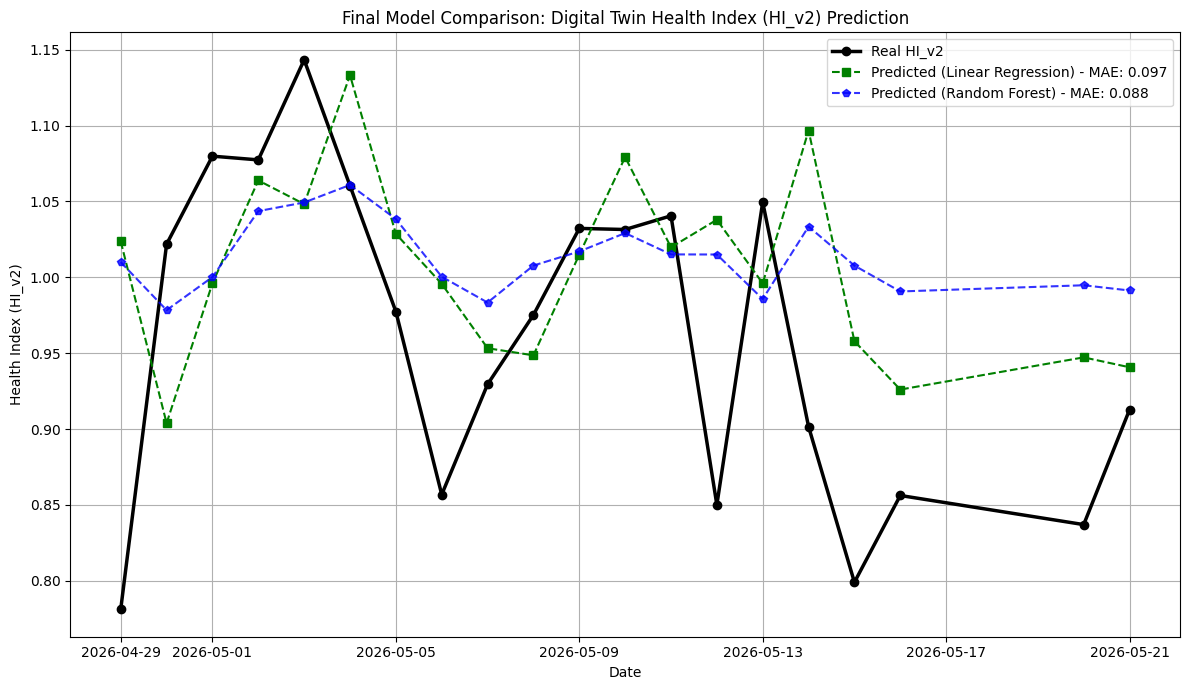

In [14]:
# Plot Professional Graph

plt.figure(figsize=(12, 7))
dates_test = df_model["date"].iloc[split:]

plt.plot(dates_test, y_test, marker='o', linestyle='-', label="Real HI_v2", color='black', linewidth=2.5)
plt.plot(dates_test, y_pred_lr, marker='s', linestyle='--', label=f"Predicted (Linear Regression) - MAE: {mae_lr:.3f}", color='green')
plt.plot(dates_test, y_pred_rf, marker='p', linestyle='--', label=f"Predicted (Random Forest) - MAE: {mae_rf:.3f}", color='blue', alpha=0.8)

plt.title("Final Model Comparison: Digital Twin Health Index (HI_v2) Prediction")
plt.xlabel("Date")
plt.ylabel("Health Index (HI_v2)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../../reports/generated/health_prediction_final_plot.png", dpi=300)
plt.show()


In [15]:
# Prepare Text Summary for Gemini

summary_text = f"""
Digital Twin Health Model Results (with HI_v2):

Linear Regression Model (HI_v2):
- MAE: {mae_lr:.4f}
- RMSE: {rmse_lr:.4f}

Random Forest Model (Tuned):
- MAE: {mae_rf:.4f}
- RMSE: {rmse_rf:.4f}

Overall Health Index (HI_v2) Stats:
- Average HI_v2: {df['HI_v2'].mean():.4f}
- Max HI_v2: {df['HI_v2'].max():.4f}
- Min HI_v2: {df['HI_v2'].min():.4f}

Please provide a scientific analysis in English, in a single paragraph,
describing the new 5-factor health index and comparing the performance
of the simple Linear Regression model vs. the more complex Random Forest model
in predicting its future values.
"""

In [17]:
# Send to Gemini

load_dotenv()
api_key = os.environ.get("GOOGLE_API_KEY")
if not api_key:
    print("Warning: GOOGLE_API_KEY not found. Skipping Gemini analysis.")
    analysis_text = "Gemini analysis skipped due to missing API key."
else:
    genai.configure(api_key=api_key)
    model_gemini = genai.GenerativeModel('gemini-2.5-flash')
    try:
        response = model_gemini.generate_content(summary_text)
        analysis_text = response.text
    except Exception as e:
        analysis_text = f"Error generating Gemini analysis: {e}"

print("\n===== Gemini Analysis =====\n")
print(analysis_text)


===== Gemini Analysis =====

The newly developed 5-factor health index (HI_v2) quantifies system health, exhibiting an average value of 0.9675, with its observed range spanning from a minimum of 0.7813 to a maximum of 1.4996, suggesting a dynamic health assessment. In predicting future values of this index, a comparative analysis between a simple Linear Regression model and a more complex, tuned Random Forest model reveals distinct performance characteristics. The Random Forest model demonstrates superior predictive accuracy, evidenced by its lower Mean Absolute Error (MAE) of 0.0877 compared to Linear Regression's 0.0971, and a reduced Root Mean Squared Error (RMSE) of 0.1098 against Linear Regression's 0.1221. This indicates that the ensemble learning approach of Random Forest, despite its increased complexity, more effectively captures the underlying non-linear relationships and interactions within the 5-factor health index, resulting in more robust and precise predictions.


In [18]:
# Save Final Report

with open("../../reports/generated/final_health_report.txt", "w", encoding="utf-8") as f:
    f.write("Digital Twin Health Project Report (Enhanced)\n")
    f.write("="*50 + "\n\n")
    f.write(summary_text)
    f.write("\n\nGemini Analysis:\n")
    f.write(analysis_text)